<a href="https://colab.research.google.com/github/KofiSmith/Machine-learning-/blob/main/DL%20Study/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import pandas as pd
import numpy as np
from glob import glob
import cv2
import matplotlib.pylab as plt

Mounted at /content/drive


In [5]:
#Pulling images from Google drive and storing them in an array
data = []
file = "https://drive.google.com/drive/folders/1SrC0bvBQZtlbVfoj5cLPpWtNMdFhjjOK"
for image_class in file:
    for image in image_class:
        data.append(image)

In [62]:

#Accessing image files from Google drive and storing them in an array with the glob function
Cats = glob('/content/drive/My Drive/Cat Dog/Cats/*')

Dogs = glob('/content/drive/My Drive/Cat Dog/Dogs/*')
target_size = (28,28)
len(Dogs), len(Cats)

(30, 30)

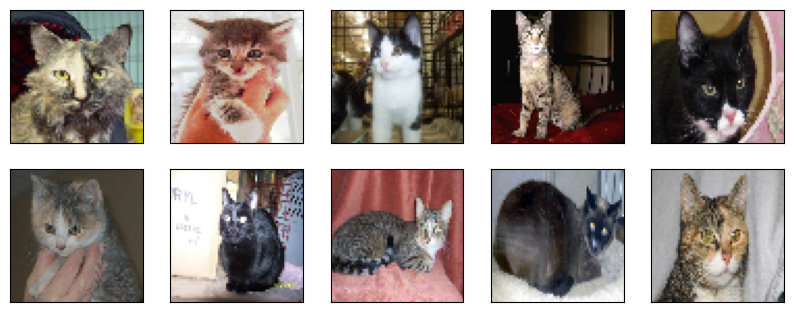

In [63]:
plt.figure(figsize=(10,10))
target_size=(64,64)

for i in range(10):
   plt.subplot(5,5, i+1)
   img = cv2.imread(Cats[i])
   #Cat = cv2.resize(Cat[i], None, fx=0.25, fy=0.25)
   #Resize the image - dsize is calculated from fx and fy
   Cat = cv2.resize(img, target_size)
   #Cat = cv2.bitwise_not(Cat)
   Cat = cv2.cvtColor(Cat, cv2.COLOR_RGB2BGR)
   plt.xticks([])
   plt.yticks([])
   plt.grid(True)
   plt.imshow(Cat)
   #plt.xlabel(class_name[Cat])

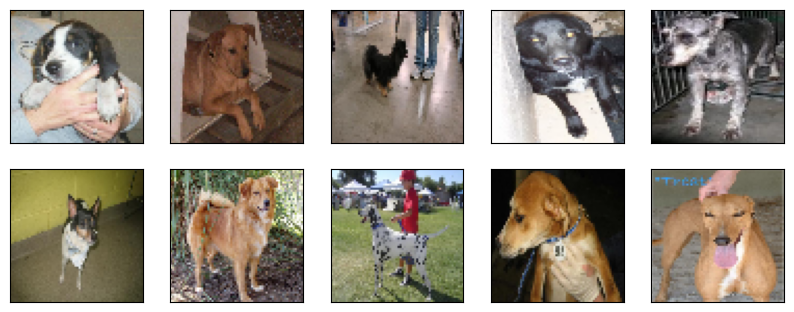

In [12]:
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5, i+1)
    img = cv2.imread(Dogs[i])
    Dog = cv2.resize(img, target_size)
    #Dog = cv2.bitwise_not(Dog)
    Dog = cv2.cvtColor(Dog, cv2.COLOR_RGB2BGR)
    plt.xticks([])
    plt.yticks([])
    plt.grid(True)
    plt.imshow(Dog)

In [65]:

#Arrays to contain the images
Cat_images = []
Dog_images = []
labels = []

#Converting the image file paths to readable cv2 images a d appending them into the arrays
target_size = (28,28)

for i in range(len(Cats)):
    img = cv2.imread(Cats[i])
    #img = cv2.bitwise_not(img)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    Cat_images.append(cv2.resize(img, target_size))
for i in range(len(Dogs)):
    img = cv2.imread(Dogs[i])
    #img = cv2.bitwise_not(img)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    Dog_images.append(cv2.resize(img, target_size))

# Convert the lists to tf.data.Dataset objects, before they can be concatenated
Cat_dataset = tf.data.Dataset.from_tensor_slices(Cat_images)
Dog_dataset = tf.data.Dataset.from_tensor_slices(Dog_images)

#Merging the image arrays together as one array of image data
Cats_and_Dogs = Dog_dataset.concatenate(Cat_dataset).shuffle(1024)

In [87]:
#Manually splitting the data set

#Getting sample sizes
train_size = int(len(Cats_and_Dogs)*0.7)
val_size = int(len(Cats_and_Dogs)*0.2)*1
test_size = int(len(Cats_and_Dogs)*0.1)*1

#Splitting the data according to the sample dizes
train = Cats_and_Dogs.take(train_size)
val = Cats_and_Dogs.skip(train_size).take(val_size)
test = Cats_and_Dogs.skip(train_size + val_size).take(test_size)

#train = train.batch(32)
len(train), len(val), len(test)

(42, 12, 6)

In [99]:
#Building the model(Setting up layers)

model = tf.keras.Sequential([
      tf.keras.layers.Flatten(input_shape=(28,28, 3)),
      tf.keras.layers.Dense(128, activation='relu'),
      tf.keras.layers.Dense(2)
      ])

In [97]:
#Compiling the model
model.compile(optimizer = 'adam',
      loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
      metrics = ['accuracy'])

In [84]:
#Training the model
model.fit(train, epochs=10)

Epoch 1/10


ValueError: None values not supported.